In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rc('font',family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']= False
plt.rcParams['font.family']
# !pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules



In [6]:
order =  pd.read_csv('C:/medicalAI/Pycham/week3/Data_processing/recommend/chipotle.csv')
print('order_count:', len(order), 'items_count', order.shape[1])

order_count: 4622 items_count 5


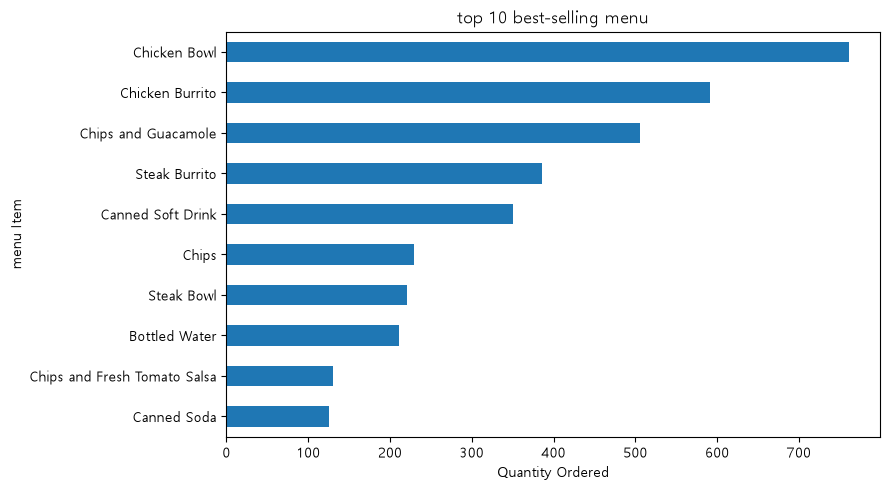

In [9]:
import pandas as pd
menu_freq = order.groupby('item_name')['quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
menu_freq.head(10)[::-1].plot(kind='barh')
plt.title('top 10 best-selling menu')
plt.xlabel('Quantity Ordered'); plt.tight_layout()
plt.ylabel('menu Item')
plt.show()

In [13]:
from mlxtend.frequent_patterns import apriori, association_rules
customerMenu = order.pivot_table(index= 'order_id', columns='item_name',
                                values='quantity', aggfunc='sum')
clean_customerMenu = customerMenu.fillna(0).map(lambda x:True if x>0 else False)
frequent = apriori(clean_customerMenu, min_support=0.02, use_colnames=True) #min-support 2%
frequent['n_items'] = frequent['itemsets'].apply(len) #apply각 행의 함수적용
frequent


,support,itemsets,n_items
0,0.029444,frozenset({6 Pack Soft Drink}),1
1,0.033261,frozenset({Barbacoa Bowl}),1
2,0.047983,frozenset({Barbacoa Burrito}),1
3,0.083969,frozenset({Bottled Water}),1
4,0.051254,frozenset({Canned Soda}),1
5,0.150491,frozenset({Canned Soft Drink}),1
6,0.036532,frozenset({Carnitas Bowl}),1
7,0.031625,frozenset({Carnitas Burrito}),1
8,0.020720,frozenset({Carnitas Soft Tacos}),1
9,0.335333,frozenset({Chicken Bowl}),1


In [14]:
print('freq item set count:', len(frequent))
print('\npair combination support top rank:')
pair = frequent[frequent['n_items']==2].sort_values('support', ascending=False)
for _, row in pair.head(6).iterrows():
    print(f"{set(row['itemsets'])} support {row['support']:.3f}")

freq item set count: 38

pair combination support top rank:
{'Chicken Bowl', 'Chips and Guacamole'} support 0.081
{'Chicken Bowl', 'Chips'} support 0.067
{'Chips and Guacamole', 'Chicken Burrito'} support 0.062
{'Chicken Bowl', 'Canned Soft Drink'} support 0.061
{'Chips and Guacamole', 'Steak Burrito'} support 0.041
{'Chicken Burrito', 'Steak Burrito'} support 0.039


In [15]:
rules = association_rules(frequent, metric='lift', min_threshold=1.0) #lift over 1
rules = rules[rules['confidence'] >=0.3].sort_values('lift', ascending=False)
view = rules.copy()
view['A(order menu)'] = view['antecedents'].apply(lambda s:','.join(s))
view['B(order with)'] = view['consequents'].apply(lambda s: ', '.join(s))
print('order by high lift')
print(view[['A(order menu)','B(order with)', 
             'support', 'confidence', 'lift']].head(8).round(3).to_string(index=False))

order by high lift
    A(order menu) B(order with)  support  confidence  lift
            Chips  Chicken Bowl    0.067       0.587 1.749
    Bottled Water  Chicken Bowl    0.038       0.448 1.336
Canned Soft Drink  Chicken Bowl    0.061       0.402 1.199


lift 우연 대비 몇 배? A 를 샀을때 B도사는 규칙. 1 이상 클수록 강한 상관관계 
confidence a살때 b도 살 확률(얼마나 강한 규칙인가, 높을수록 확실). 
support a, b를 동시에 포함하는 전체 중 비율(너무 낮으면 드문 규칙)